In [2]:
import numpy as np
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf, fetch_map

# Load cortical surface mesh
surf, medmask = fetch_surf()

# Initialise solver with surface
solver = EigenSolver(surf, mask=medmask).solve(10)

In [3]:
# Get vertex coords
verts = surf.v

# Normalise mesh and pass to solver
surf.normalize_()

# Verify that normalized vertices are different
verts_norm = surf.v

assert not np.allclose(verts, verts_norm), "Vertices were not normalized properly."

In [4]:
# Check whether norm solver has different mass and stiffness
solver_norm = EigenSolver(surf, mask=medmask).solve(10)

# print correlations
print("Correlation between original and normalized mass matrices:", np.corrcoef(solver.mass.data.flatten(), solver_norm.mass.data.flatten())[0, 1])
print("Correlation between original and normalized stiffness matrices:", np.corrcoef(solver.stiffness.data.flatten(), solver_norm.stiffness.data.flatten())[0, 1])

# print summed diffs
print("Sum of absolute differences between original and normalized mass matrices:", np.sum(np.abs(solver.mass.data - solver_norm.mass.data)))
print("Sum of absolute differences between original and normalized stiffness matrices:", np.sum(np.abs(solver.stiffness.data - solver_norm.stiffness.data)))

Correlation between original and normalized mass matrices: 0.9999999999996269
Correlation between original and normalized stiffness matrices: 0.9999999999995576
Sum of absolute differences between original and normalized mass matrices: 63563.93263538163
Sum of absolute differences between original and normalized stiffness matrices: 0.2285130853369992


In [5]:
# Check mode correlation and summed diff
print("Correlation between original and normalized modes:", np.corrcoef(solver.emodes.flatten(), solver_norm.emodes.flatten())[0, 1])
print("Sum of absolute differences between original and normalized modes:", np.sum(np.abs(solver.emodes - solver_norm.emodes)))

Correlation between original and normalized modes: 0.9999999999992787
Sum of absolute differences between original and normalized modes: 267323.86838186265


He's right...

Mass matrix, not stiffness matrix, changes under mesh rescaling. Modes also change, likely
preserving decomposition coefficients. If so, eigenstrapping and wave model can be run with
normalized eigenvalues.

[[333.06403779]
 [ 11.11242474]
 [ 17.34712275]
 [ -3.00473552]
 [ -8.53999966]
 [ -8.55517896]
 [  3.79951114]
 [ -2.70504227]
 [ -9.01436388]
 [  2.36732244]] [[ 1.26513348]
 [ 0.0422102 ]
 [ 0.06589364]
 [-0.01141319]
 [-0.03243879]
 [-0.03249652]
 [ 0.01443206]
 [-0.01027492]
 [-0.03424079]
 [ 0.00899239]]
[[1.        ]
 [1.00000018]
 [0.99998288]
 [1.00001811]
 [1.00000414]
 [1.00000207]
 [1.00001836]
 [1.0000101 ]
 [0.99999976]
 [0.99997912]]


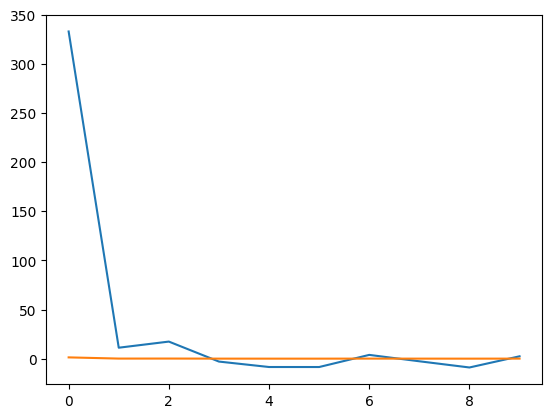

In [19]:
# Check that decomposition coefficients are preserved
myelinmap = fetch_map('myelinmap')[medmask]

beta = solver.decompose(myelinmap)
beta_norm = solver_norm.decompose(myelinmap)

print(beta, beta_norm)

print((beta / beta[0]) / (beta_norm / beta_norm[0]))

import matplotlib.pyplot as plt

plt.plot(beta)
plt.plot(beta_norm)
plt.show()


Nevermind...